In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
df=files.upload()

Saving AB_NYC_2019.csv to AB_NYC_2019 (3).csv


In [4]:
df=pd.read_csv("AB_NYC_2019.csv")

In [5]:
df.shape

(48895, 16)

In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [8]:
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [9]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["price"].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [12]:
df["minimum_nights"].describe()

,minimum_nights
count,48895.000000
mean,7.029962
std,20.510550
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1250.000000


In [13]:
df["last_review"]=pd.to_datetime(df["last_review"])

In [14]:
df["reviews_per_month"]=df["reviews_per_month"].fillna(0)

In [15]:
df["name"]=df["name"].fillna("unknown")

In [16]:
df["host_name"]=df["host_name"].fillna("unknown")

In [17]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [18]:
df.groupby("neighbourhood_group")["price"].mean()

,price
neighbourhood_group,
Bronx,87.496792
Brooklyn,124.383207
Manhattan,196.875814
Queens,99.517649
Staten Island,114.812332


In [19]:
df.groupby("room_type")["price"].mean()

,price
room_type,
Entire home/apt,211.794246
Private room,89.780973
Shared room,70.127586


In [20]:
df["room_type"].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


In [21]:
df["neighbourhood_group"].value_counts().head(5)

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


In [22]:
df.groupby("host_name")["id"].count().sort_values(ascending=False).head(10)

,id
host_name,
Michael,417
David,403
Sonder (NYC),327
John,294
Alex,279
Blueground,232
Sarah,227
Daniel,226
Jessica,205


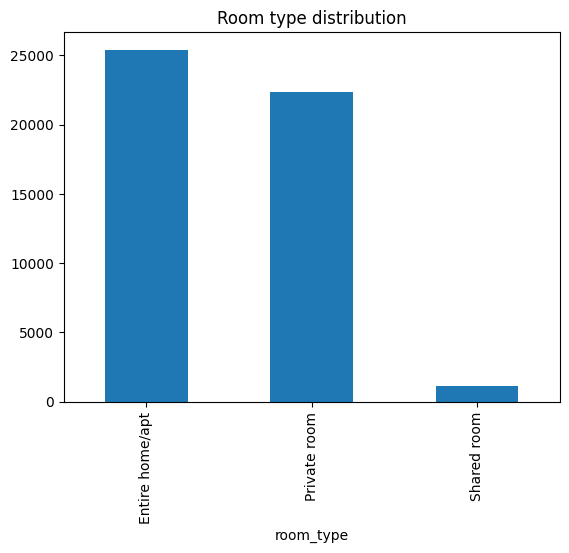

In [23]:
df["room_type"].value_counts().plot(kind="bar")
plt.title("Room type distribution")
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [34]:
df=df[df["price"]<1000]

In [35]:
selected_features = [
    "neighbourhood_group",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]
X = df[selected_features]
y = df["price"]
X = pd.get_dummies(X)

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [38]:
predictions = model.predict(X_test)
predictions

array([ 61.68751244, 163.09906834,  63.63912431, ...,  62.69254966,
       129.34903813, 108.54621188])

In [39]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(mae)
print(r2)

54.9593262219282
0.3154270614952557


In [40]:
from sklearn.ensemble import RandomForestRegressor
model1= RandomForestRegressor(
    n_estimators=100,
    random_state=42)

model1.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [41]:
predictions1 = model.predict(X_test)
predictions1

array([ 61.68751244, 163.09906834,  63.63912431, ...,  62.69254966,
       129.34903813, 108.54621188])

In [42]:
mae = mean_absolute_error(y_test, predictions1)
r2 = r2_score(y_test, predictions1)
print(mae)
print(r2)

54.9593262219282
0.3154270614952557


In [43]:
from google.colab import files
df.to_csv("AB_NYC_2019.csv", index=False)
files.download("AB_NYC_2019.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>